In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [2]:
train = pd.read_csv('df_pre.csv')
test = pd.read_csv('data_test.csv')

print(train.shape, test.shape)
train.head()

(486, 6) (17, 6)


,OGIP,well_count,productivity_index,gas_compressibility,effective_condensate,kh
0,3109.522101,21.098571,8.044826e+07,7823.191339,67368.669193,15568.290515
1,5981.811186,20.596850,1.685454e+08,8452.123409,53008.952626,16011.524988
2,4339.931660,7.399649,1.506337e+08,10656.101389,77949.528731,24525.417445
3,5950.383478,20.601115,1.674518e+08,8447.009884,53176.532379,15988.679300
4,834.571790,4.185260,4.534929e+06,9922.388347,19191.424270,3347.055791


In [3]:
def formula(ogip):
    return 0.0011 * ogip + 11

train['base_pred'] = formula(train['OGIP'])
test['base_pred'] = formula(test['OGIP'])

train['residual'] = train['well_count'] - train['base_pred']

print('formula - Test MAE:', mean_absolute_error(test['well_count'], test['base_pred']))
print('formula - Test R2 :', r2_score(test['well_count'], test['base_pred'])) 

formula - Test MAE: 5.793168235294117
formula - Test R2 : 0.696699293250916


In [4]:
features = ['OGIP', 'productivity_index', 'gas_compressibility', 'effective_condensate', 'kh']

X_train = train[features]
y_train_res = train['residual']

X_test = test[features]
y_test = test['well_count']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
svr = SVR(kernel='rbf', C=1, epsilon=1.0)

cv_scores_svr = -cross_val_score(svr, X_train_scaled, y_train_res, cv=kfold, scoring='neg_mean_absolute_error')
print('SVR - CV MAE residual:', cv_scores_svr.mean(), '+/-', cv_scores_svr.std())

svr.fit(X_train_scaled, y_train_res)

svr_train_pred = train['base_pred'] + svr.predict(X_train_scaled)
svr_test_pred = test['base_pred'] + svr.predict(X_test_scaled)

print('SVR hybrid -> Train MAE:', mean_absolute_error(train['well_count'], svr_train_pred), ' | Test MAE:', mean_absolute_error(y_test, svr_test_pred))
print('SVR hybrid -> Train R2 :', r2_score(train['well_count'], svr_train_pred), ' | Test R2 :', r2_score(y_test, svr_test_pred))

SVR - CV MAE residual: 2.0209355072315667 +/- 0.16169846621918585
SVR hybrid -> Train MAE: 1.7462251188978708  | Test MAE: 1.9248717449443296
SVR hybrid -> Train R2 : 0.9566378173966106  | Test R2 : 0.9675346711738597


In [40]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,       
    min_samples_leaf=10, 
    random_state=42,
)

cv_scores_gbr = -cross_val_score(gbr, X_train_scaled, y_train_res, cv=kfold, scoring='neg_mean_absolute_error')
print('GBR - CV MAE residual:', cv_scores_gbr.mean(), '+/-', cv_scores_gbr.std())

gbr.fit(X_train_scaled, y_train_res)

gbr_train_pred = train['base_pred'] + gbr.predict(X_train_scaled)
gbr_test_pred = test['base_pred'] + gbr.predict(X_test_scaled)

print('GBR hybrid -> Train MAE:', mean_absolute_error(train['well_count'], gbr_train_pred), ' | Test MAE:', mean_absolute_error(y_test, gbr_test_pred))
print('GBR hybrid -> Train R2 :', r2_score(train['well_count'], gbr_train_pred), ' | Test R2 :', r2_score(y_test, gbr_test_pred))

GBR - CV MAE residual: 2.3431066388200663 +/- 0.2101209615495393
GBR hybrid -> Train MAE: 2.2262472663384707  | Test MAE: 2.4244104994467968
GBR hybrid -> Train R2 : 0.9348331067905844  | Test R2 : 0.956135219528706


In [41]:
xgb = XGBRegressor(
    n_estimators=120,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1,     
    reg_lambda=5,    
    random_state=42,
    verbosity=0,
)

cv_scores_xgb = -cross_val_score(xgb, X_train_scaled, y_train_res, cv=kfold, scoring='neg_mean_absolute_error')
print('XGB - CV MAE residual:', cv_scores_xgb.mean(), '+/-', cv_scores_xgb.std())

xgb.fit(X_train_scaled, y_train_res)

xgb_train_pred = train['base_pred'] + xgb.predict(X_train_scaled)
xgb_test_pred = test['base_pred'] + xgb.predict(X_test_scaled)

print('XGB hybrid -> Train MAE:', mean_absolute_error(train['well_count'], xgb_train_pred), ' | Test MAE:', mean_absolute_error(y_test, xgb_test_pred))
print('XGB hybrid -> Train R2 :', r2_score(train['well_count'], xgb_train_pred), ' | Test R2 :', r2_score(y_test, xgb_test_pred))

XGB - CV MAE residual: 2.4308078398597925 +/- 0.2465456416676492
XGB hybrid -> Train MAE: 2.2160551133700985  | Test MAE: 2.5116071971377196
XGB hybrid -> Train R2 : 0.935569448115553  | Test R2 : 0.9509804247940896


In [8]:
results = pd.DataFrame({
    'model': ['Formula only', 'SVR hybrid', 'GBR hybrid', 'XGB hybrid'],
    'test_MAE': [
        mean_absolute_error(y_test, test['base_pred']),
        mean_absolute_error(y_test, svr_test_pred),
        mean_absolute_error(y_test, gbr_test_pred),
        mean_absolute_error(y_test, xgb_test_pred),
    ],
    'test_R2': [
        r2_score(y_test, test['base_pred']),
        r2_score(y_test, svr_test_pred),
        r2_score(y_test, gbr_test_pred),
        r2_score(y_test, xgb_test_pred),
    ],
})

results.sort_values('test_MAE')

,model,test_MAE,test_R2
1,SVR hybrid,1.924872,0.967535
2,GBR hybrid,2.424410,0.956135
3,XGB hybrid,2.511607,0.950980
0,Formula only,5.793168,0.696699


In [9]:
row_by_row = pd.DataFrame({
    'actual': y_test.values,
    'SVR_pred': svr_test_pred.values,
    'GBR_pred': gbr_test_pred.values,
    'XGB_pred': xgb_test_pred.values,
})

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
row_by_row

,actual,SVR_pred,GBR_pred,XGB_pred
0,9,10.42,12.58,12.69
1,18,19.76,20.89,21.07
2,12,11.11,10.82,10.68
3,43,43.21,42.45,42.89
4,13,12.86,13.08,13.30
5,20,14.96,15.47,15.51
6,33,32.20,30.93,29.45
7,49,47.06,50.62,48.19
8,20,24.41,22.85,24.94
9,21,18.71,18.58,18.57


In [10]:
import matplotlib.pyplot as plt

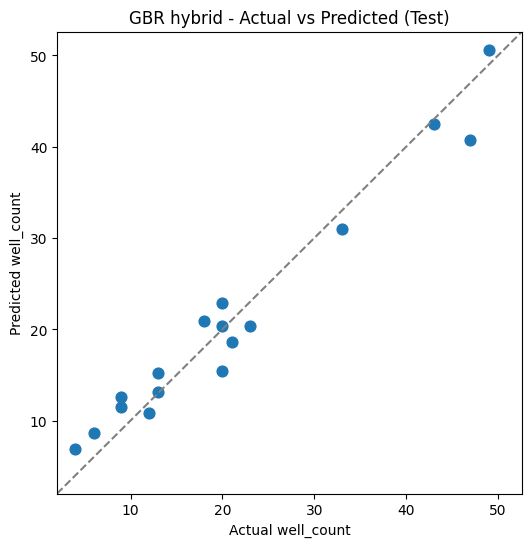

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, gbr_test_pred, s=60)
lims = [min(y_test.min(), gbr_test_pred.min()) - 2, max(y_test.max(), gbr_test_pred.max()) + 2]
plt.plot(lims, lims, '--', color='gray')  
plt.xlabel('Actual well_count')
plt.ylabel('Predicted well_count')
plt.title('GBR hybrid - Actual vs Predicted (Test)')
plt.xlim(lims)
plt.ylim(lims)
plt.show()

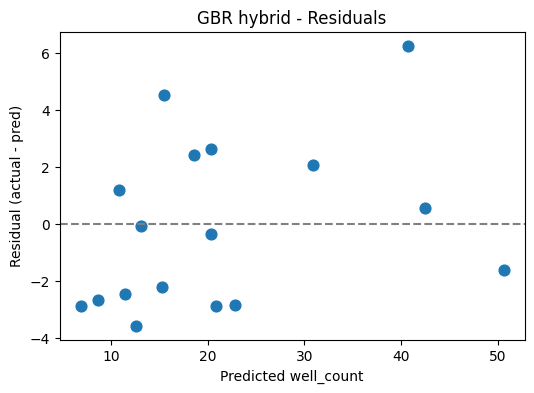

In [12]:
gbr_residuals = y_test.values - gbr_test_pred.values

plt.figure(figsize=(6, 4))
plt.scatter(gbr_test_pred, gbr_residuals, s=60)
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Predicted well_count')
plt.ylabel('Residual (actual - pred)')
plt.title('GBR hybrid - Residuals')
plt.show()

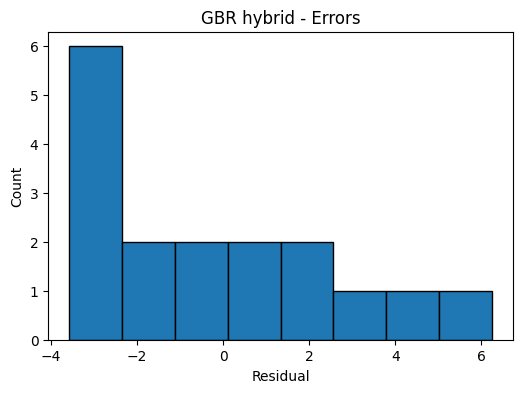

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(gbr_residuals, bins=8, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('GBR hybrid - Errors')
plt.show()

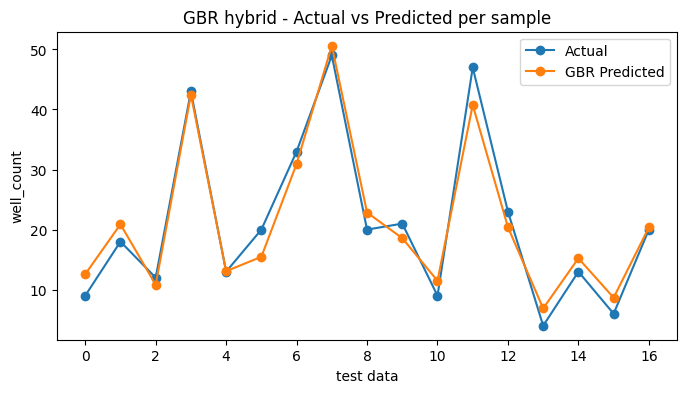

In [14]:
idx = np.arange(len(y_test))

plt.figure(figsize=(8, 4))
plt.plot(idx, y_test.values, 'o-', label='Actual')
plt.plot(idx, gbr_test_pred.values, 'o-', label='GBR Predicted')
plt.xlabel('test data')
plt.ylabel('well_count')
plt.title('GBR hybrid - Actual vs Predicted per sample')
plt.legend()
plt.show()

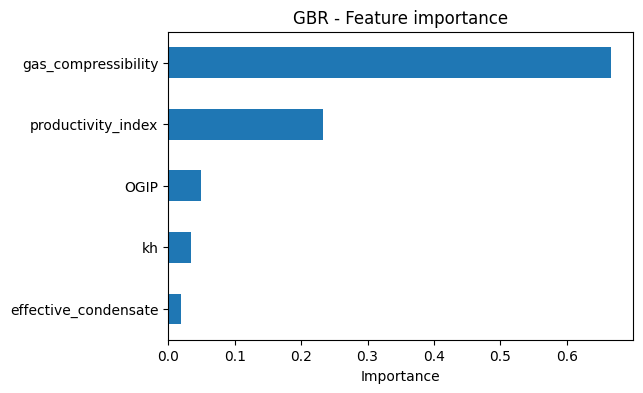

In [15]:
importances = pd.Series(gbr.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 4))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('GBR - Feature importance')
plt.show()

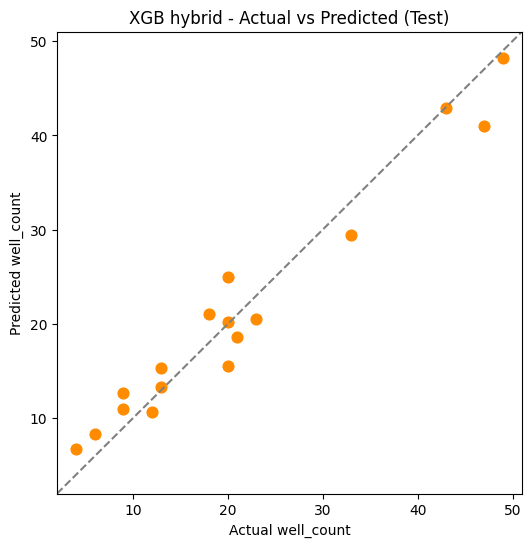

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_test_pred, s=60, color='darkorange')
lims = [min(y_test.min(), xgb_test_pred.min()) - 2, max(y_test.max(), xgb_test_pred.max()) + 2]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('Actual well_count')
plt.ylabel('Predicted well_count')
plt.title('XGB hybrid - Actual vs Predicted (Test)')
plt.xlim(lims)
plt.ylim(lims)
plt.show()

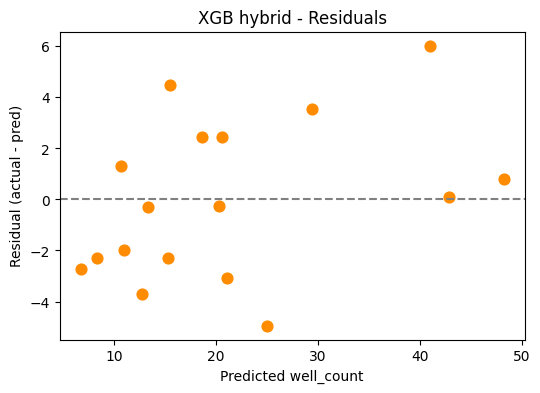

In [17]:
xgb_residuals = y_test.values - xgb_test_pred.values

plt.figure(figsize=(6, 4))
plt.scatter(xgb_test_pred, xgb_residuals, s=60, color='darkorange')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Predicted well_count')
plt.ylabel('Residual (actual - pred)')
plt.title('XGB hybrid - Residuals')
plt.show()

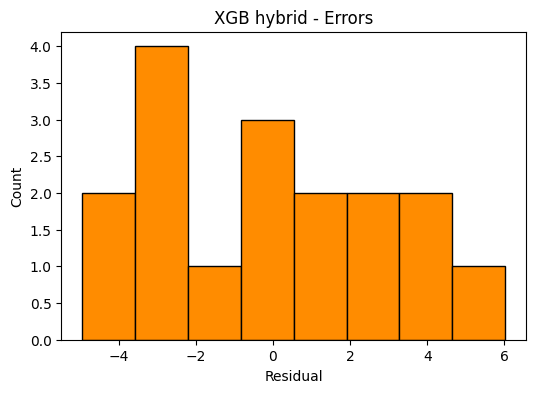

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(xgb_residuals, bins=8, edgecolor='black', color='darkorange')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('XGB hybrid - Errors')
plt.show()

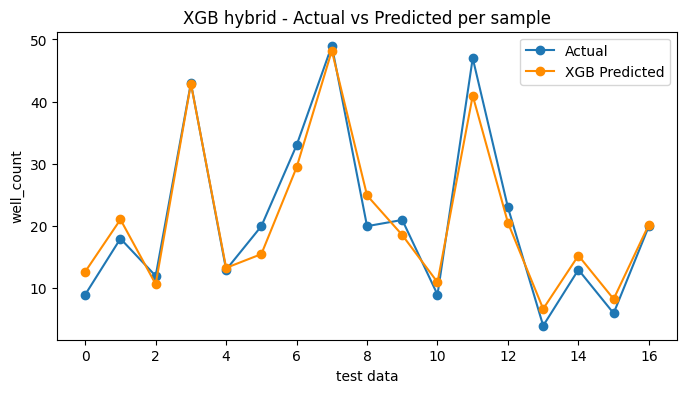

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(idx, y_test.values, 'o-', label='Actual')
plt.plot(idx, xgb_test_pred.values, 'o-', label='XGB Predicted', color='darkorange')
plt.xlabel('test data')
plt.ylabel('well_count')
plt.title('XGB hybrid - Actual vs Predicted per sample')
plt.legend()
plt.show()

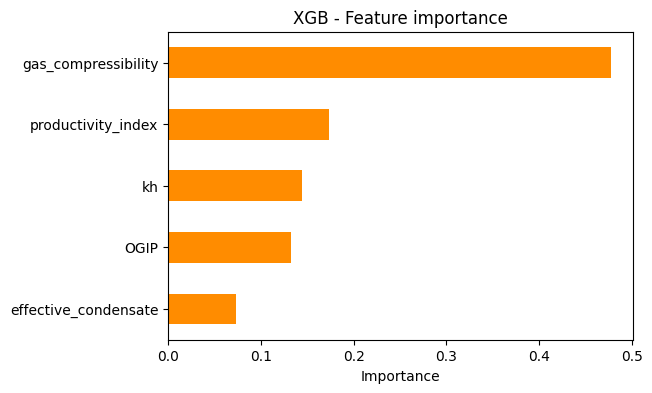

In [20]:
xgb_importances = pd.Series(xgb.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 4))
xgb_importances.plot(kind='barh', color='darkorange')
plt.xlabel('Importance')
plt.title('XGB - Feature importance')
plt.show()

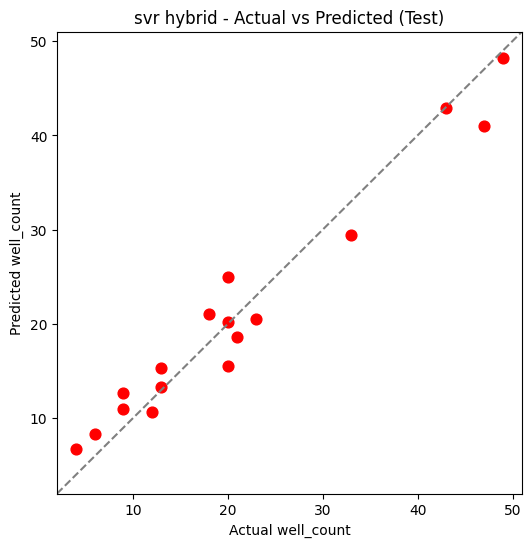

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_test_pred, s=60, color='red')
lims = [min(y_test.min(), xgb_test_pred.min()) - 2, max(y_test.max(), xgb_test_pred.max()) + 2]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('Actual well_count')
plt.ylabel('Predicted well_count')
plt.title('svr hybrid - Actual vs Predicted (Test)')
plt.xlim(lims)
plt.ylim(lims)
plt.show()

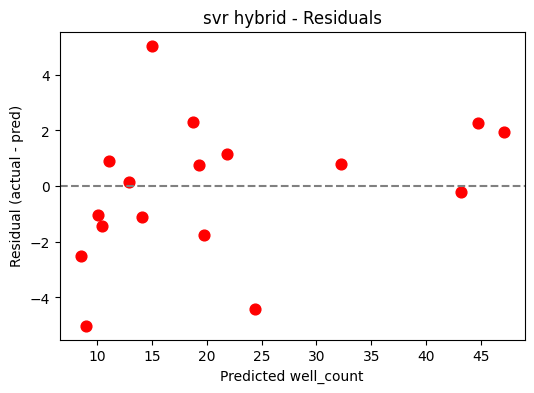

In [22]:
svr_residuals = y_test.values - svr_test_pred.values

plt.figure(figsize=(6, 4))
plt.scatter(svr_test_pred, svr_residuals, s=60, color='red')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Predicted well_count')
plt.ylabel('Residual (actual - pred)')
plt.title('svr hybrid - Residuals')
plt.show()

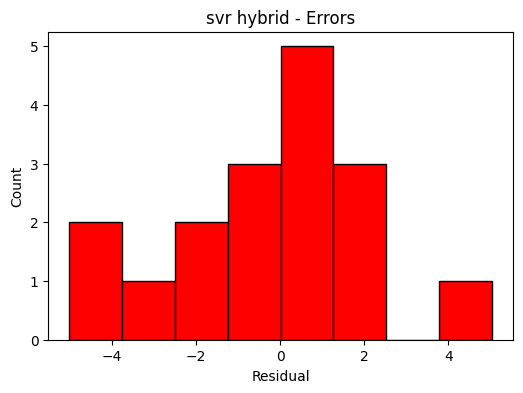

In [23]:
plt.figure(figsize=(6, 4))
plt.hist(svr_residuals, bins=8, edgecolor='black', color='red')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('svr hybrid - Errors')
plt.show()

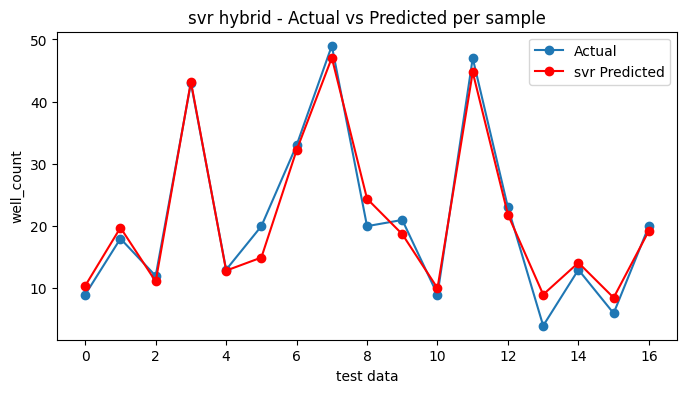

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(idx, y_test.values, 'o-', label='Actual')
plt.plot(idx, svr_test_pred.values, 'o-', label='svr Predicted', color='red')
plt.xlabel('test data')
plt.ylabel('well_count')
plt.title('svr hybrid - Actual vs Predicted per sample')
plt.legend()
plt.show()

features

Kh= k_avg * h

productivity_index =( OGIP * h * k_avg ) / gas_density

gas_compressibility = pressure / gas_density


effective_condensate = condensate * pressure

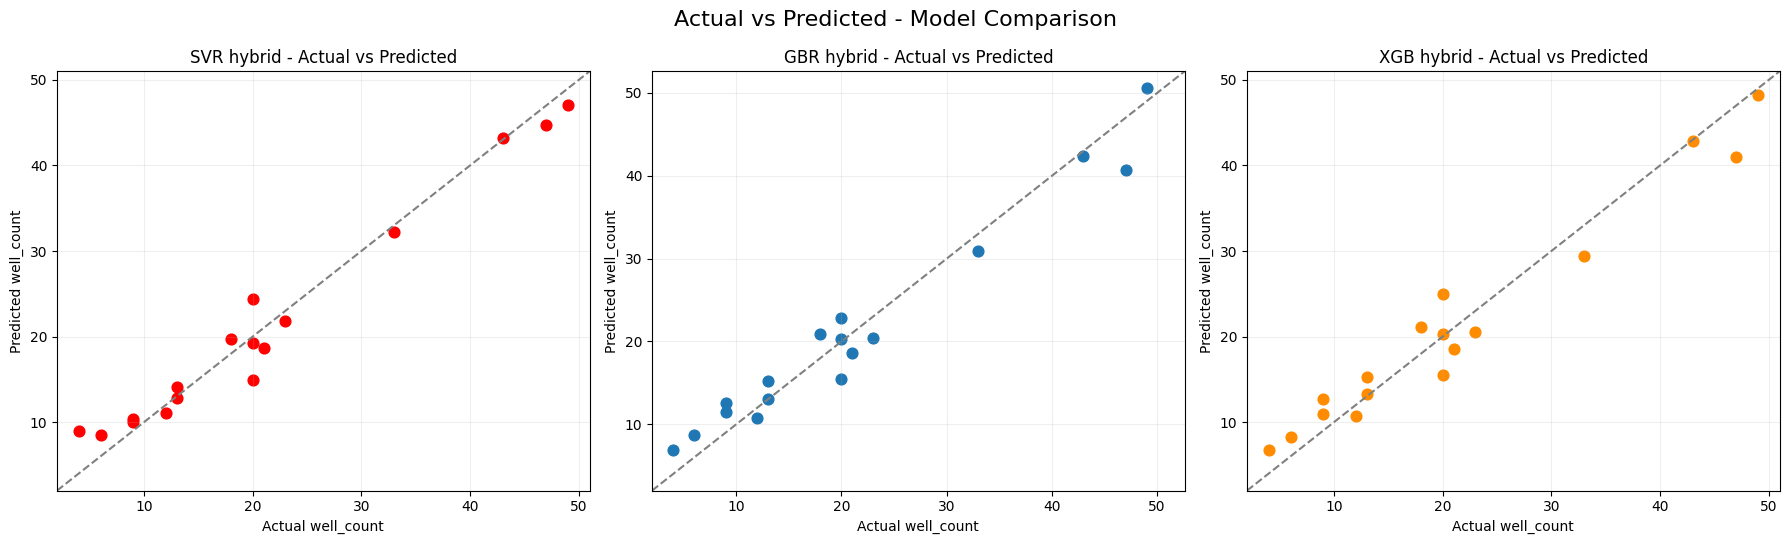

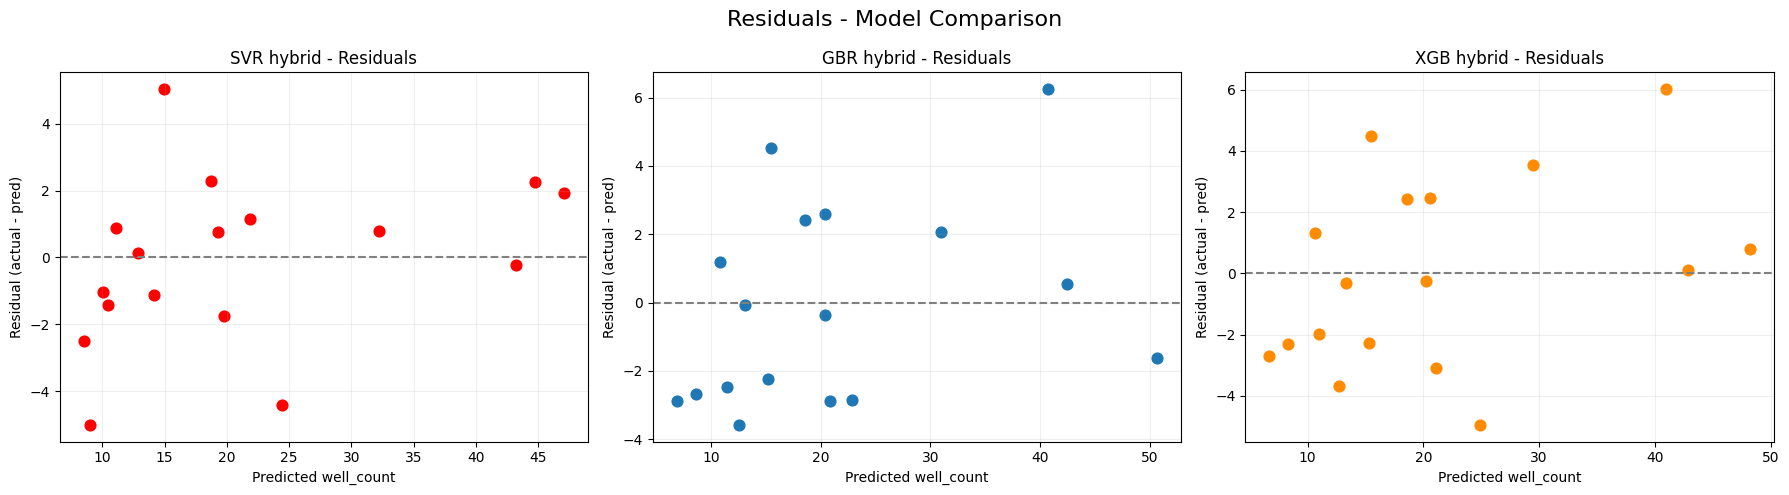

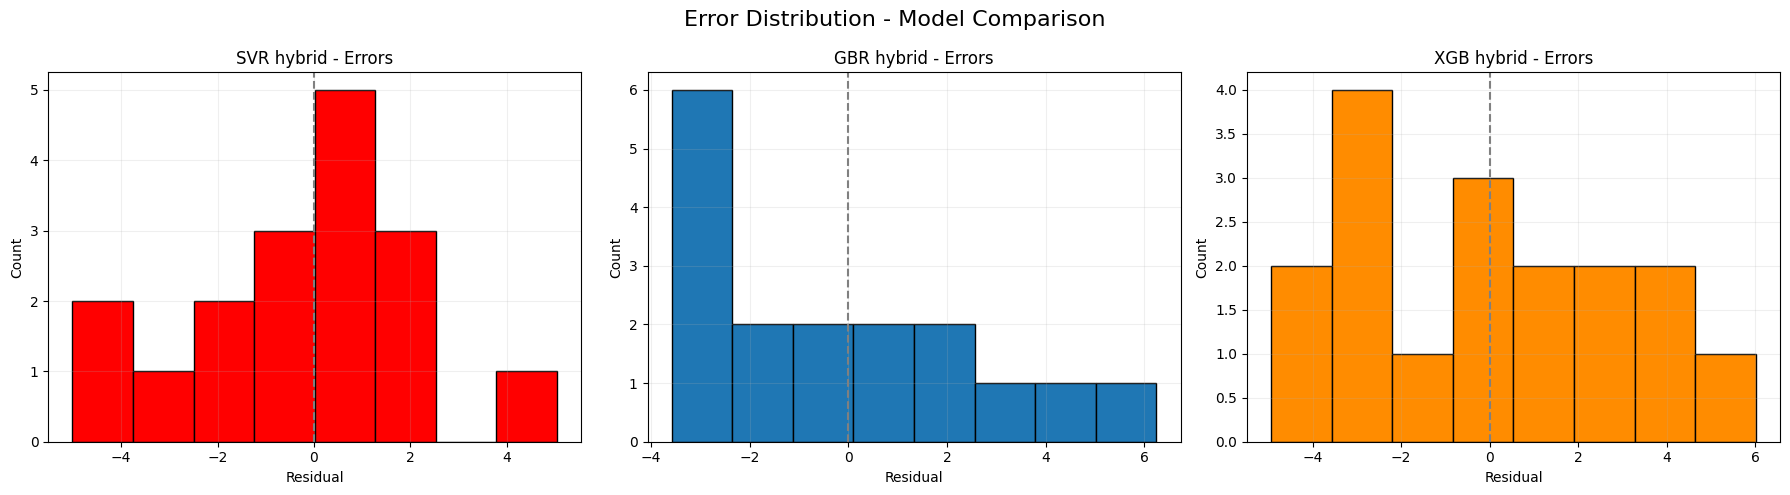

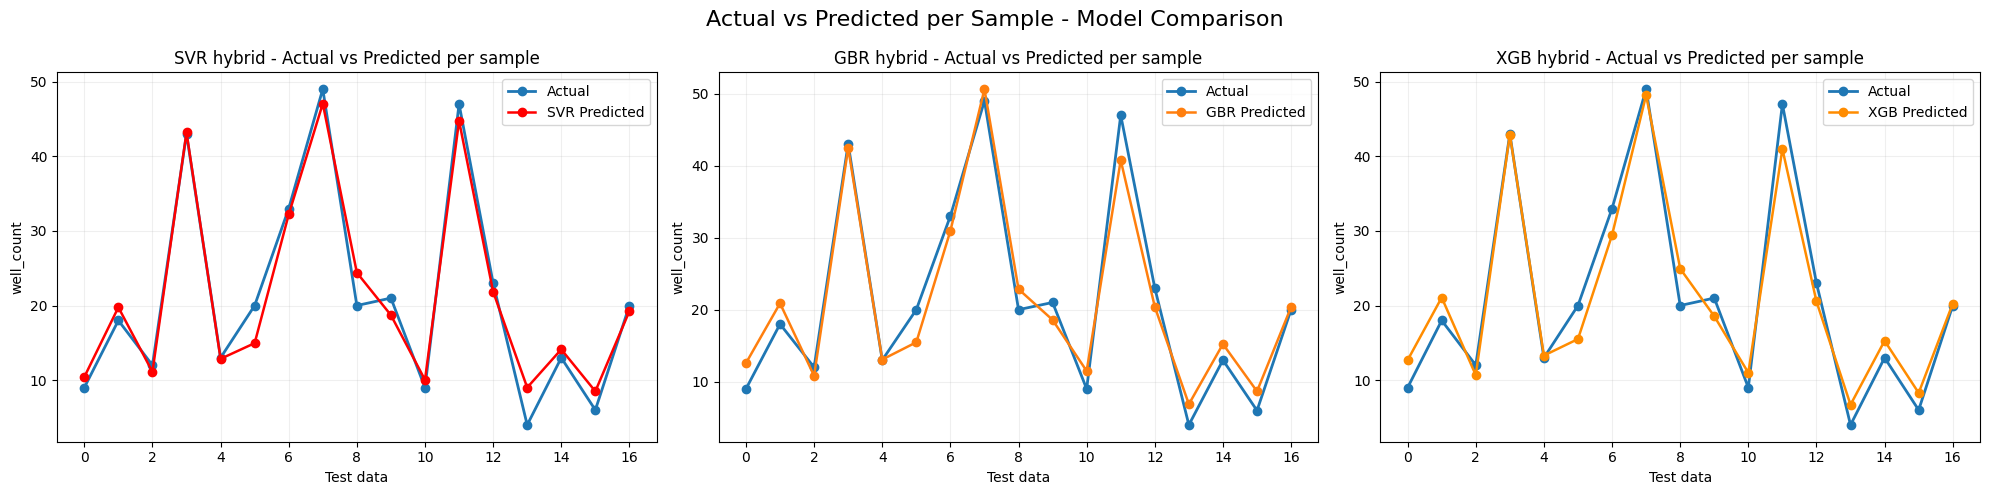

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


models = {
    'SVR': svr_test_pred.values,
    'GBR': gbr_test_pred.values,
    'XGB': xgb_test_pred.values
}


model_colors = {
    'SVR': 'red',
    'GBR': None,
    'XGB': 'darkorange'
}

y_true = y_test.values
idx = np.arange(len(y_true))

# Residuals
residuals = {
    model: y_true - pred
    for model, pred in models.items()
}



fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.5)
)

for ax, (model, pred) in zip(axes, models.items()):

    color = model_colors[model]

    if color is None:
        ax.scatter(
            y_true,
            pred,
            s=60
        )
    else:
        ax.scatter(
            y_true,
            pred,
            s=60,
            color=color
        )

   
    lims = [
        min(y_true.min(), pred.min()) - 2,
        max(y_true.max(), pred.max()) + 2
    ]

    ax.plot(
        lims,
        lims,
        '--',
        color='gray'
    )

    ax.set_xlabel('Actual well_count')
    ax.set_ylabel('Predicted well_count')
    ax.set_title(f'{model} hybrid - Actual vs Predicted')

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.grid(alpha=0.2)


plt.suptitle(
    'Actual vs Predicted - Model Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()




fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, (model, pred) in zip(axes, models.items()):

    color = model_colors[model]
    res = residuals[model]

    if color is None:
        ax.scatter(
            pred,
            res,
            s=60
        )
    else:
        ax.scatter(
            pred,
            res,
            s=60,
            color=color
        )

  
    ax.axhline(
        0,
        linestyle='--',
        color='gray'
    )

    ax.set_xlabel('Predicted well_count')
    ax.set_ylabel('Residual (actual - pred)')
    ax.set_title(f'{model} hybrid - Residuals')

    ax.grid(alpha=0.2)


plt.suptitle(
    'Residuals - Model Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, (model, res) in zip(axes, residuals.items()):

    color = model_colors[model]

    if color is None:
        ax.hist(
            res,
            bins=8,
            edgecolor='black'
        )
    else:
        ax.hist(
            res,
            bins=8,
            edgecolor='black',
            color=color
        )

    ax.axvline(
        0,
        linestyle='--',
        color='gray'
    )

    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{model} hybrid - Errors')

    ax.grid(alpha=0.2)


plt.suptitle(
    'Error Distribution - Model Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 5)
)

for ax, (model, pred) in zip(axes, models.items()):

    color = model_colors[model]

    
    ax.plot(
        idx,
        y_true,
        'o-',
        label='Actual',
        linewidth=2
    )

    
    if color is None:
        ax.plot(
            idx,
            pred,
            'o-',
            label=f'{model} Predicted',
            linewidth=1.8
        )
    else:
        ax.plot(
            idx,
            pred,
            'o-',
            label=f'{model} Predicted',
            color=color,
            linewidth=1.8
        )

    ax.set_xlabel('Test data')
    ax.set_ylabel('well_count')
    ax.set_title(
        f'{model} hybrid - Actual vs Predicted per sample'
    )

    ax.legend()
    ax.grid(alpha=0.2)


plt.suptitle(
    'Actual vs Predicted per Sample - Model Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()


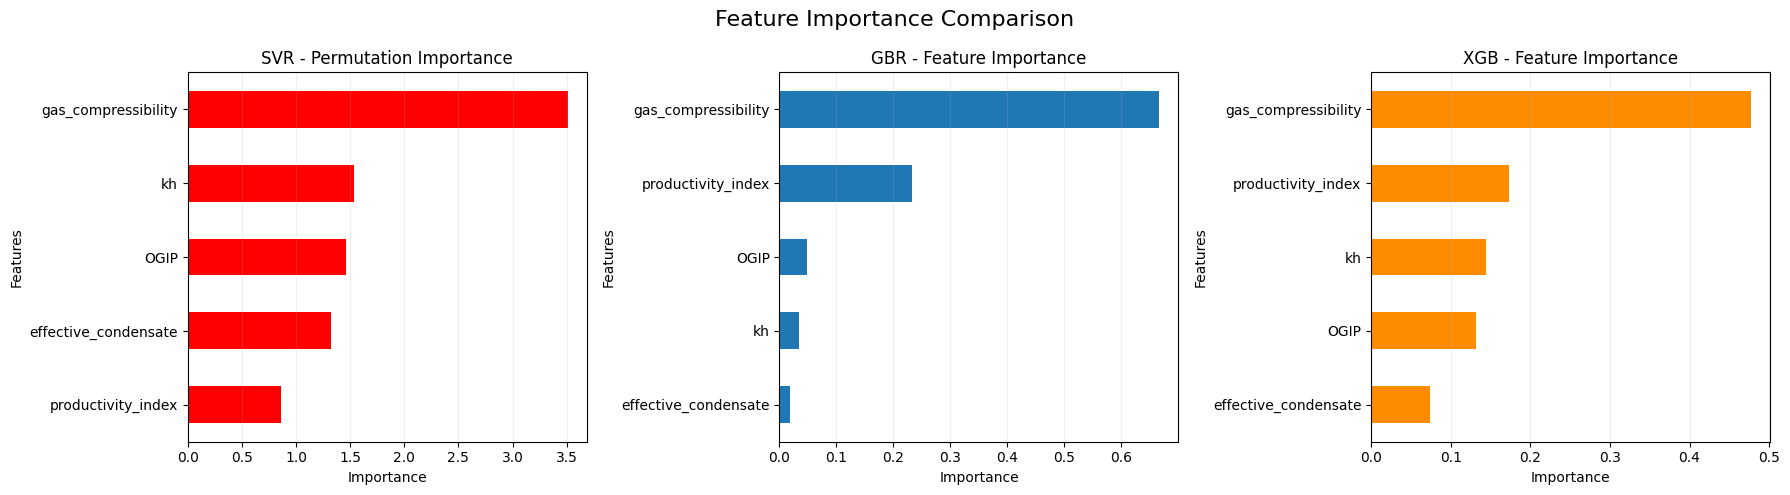

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance



gbr_importances = pd.Series(
    gbr.feature_importances_,
    index=features
).sort_values()




xgb_importances = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values()



svr_perm = permutation_importance(
    svr,
    X_test_scaled,
    y_test - test['base_pred'],
    scoring='neg_mean_absolute_error',
    n_repeats=20,
    random_state=42
)

svr_importances = pd.Series(
    svr_perm.importances_mean,
    index=features
).sort_values()




fig, axes = plt.subplots(1, 3, figsize=(18, 5))



svr_importances.plot(
    kind='barh',
    ax=axes[0],
    color='red'
)

axes[0].set_title('SVR - Permutation Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Features')
axes[0].grid(axis='x', alpha=0.2)



gbr_importances.plot(
    kind='barh',
    ax=axes[1]
)

axes[1].set_title('GBR - Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Features')
axes[1].grid(axis='x', alpha=0.2)


xgb_importances.plot(
    kind='barh',
    ax=axes[2],
    color='darkorange'
)

axes[2].set_title('XGB - Feature Importance')
axes[2].set_xlabel('Importance')
axes[2].set_ylabel('Features')
axes[2].grid(axis='x', alpha=0.2)



plt.suptitle(
    'Feature Importance Comparison',
    fontsize=16
)

plt.tight_layout()
plt.show()



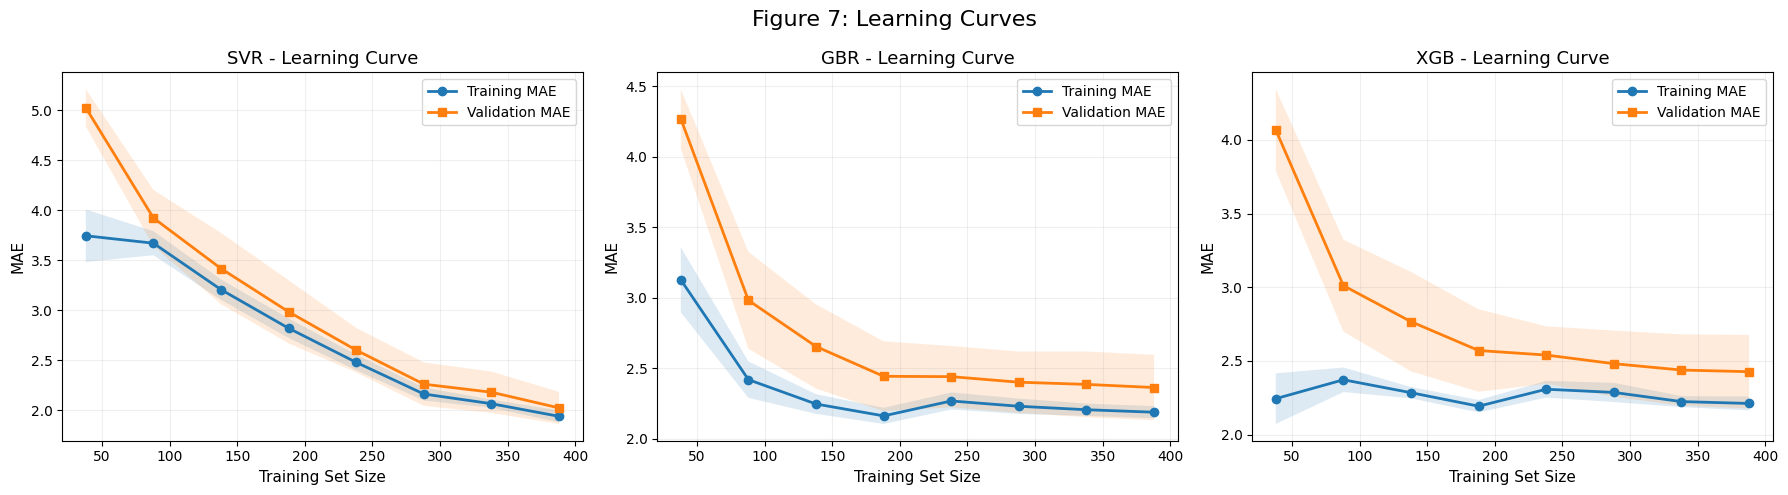

In [ ]:

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

models = {
    'SVR': svr,
    'GBR': gbr,
    'XGB': xgb
}

model_colors = {
    'SVR': 'red',
    'GBR': None,
    'XGB': 'darkorange'
}

train_sizes = np.linspace(0.1, 1.0, 8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):

    sizes, train_scores, val_scores = learning_curve(
        model,
        X_train_scaled,
        y_train_res,
        cv=kfold,
        scoring='neg_mean_absolute_error',
        train_sizes=train_sizes,
        n_jobs=-1
    )

    # Convert negative MAE to positive MAE
    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    # Training curve
    ax.plot(
        sizes,
        train_mae,
        marker='o',
        linewidth=2,
        label='Training MAE'
    )

    # Validation curve
    ax.plot(
        sizes,
        val_mae,
        marker='s',
        linewidth=2,
        label='Validation MAE'
    )

    # Standard deviation bands
    ax.fill_between(
        sizes,
        train_mae - train_std,
        train_mae + train_std,
        alpha=0.15
    )

    ax.fill_between(
        sizes,
        val_mae - val_std,
        val_mae + val_std,
        alpha=0.15
    )

    ax.set_title(f'{name} - Learning Curve', fontsize=13)
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('MAE', fontsize=11)

    ax.grid(
        axis='both',
        alpha=0.2
    )

    ax.legend()

plt.suptitle(
    'Figure 7: Learning Curves',
    fontsize=16
)

plt.tight_layout()
plt.show()

